## Model 3: Encoder-Decoder + Additive (Bahdanau) Attention


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

from data_prep import load_split_data, device, MAX_LENGTH, SOS_token, EOS_token, PAD_token, UNK_token, RANDOM_STATE
from train_utils import train, plot_losses, evaluate, evaluateRandomly, compute_bleu, save_result, count_parameters, perplexity, measure_inference_latency

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print(f"device = {device} | random_state = {RANDOM_STATE}")

device = cpu | random_state = 20


In [2]:
data = load_split_data(batch_size=64)
input_lang, output_lang = data["input_lang"], data["output_lang"]
train_pairs, val_pairs, test_pairs = data["train_pairs"], data["val_pairs"], data["test_pairs"]
train_loader, val_loader = data["train_loader"], data["val_loader"]

Read 331266 sentence pairs
Trimmed to 271824 pairs (< 10 tokens/sentence)
Sampled subset (random_state=20): 8000 pairs
Vocab sizes -> deu: 5743 words | eng: 4028 words
Train: 6400 | Val: 800 | Test: 800


In [3]:
class EncoderRNN(nn.Module):
    """Same as Notebook 02, but here we actually USE every timestep of
    encoder_outputs (not just the final hidden state)."""
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded)
        return output, hidden


class AdditiveAttention(nn.Module):
    """Bahdanau-style attention: score = v^T tanh(W1*h_i + W2*s_{t-1})."""
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)   # applied to encoder outputs
        self.Ua = nn.Linear(hidden_size, hidden_size)   # applied to decoder hidden state
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # query: decoder hidden state (batch,1,hidden); keys: encoder outputs (batch,seq,hidden)
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))   # (batch, seq, 1)
        scores = scores.squeeze(-1).unsqueeze(1)                        # (batch, 1, seq)
        weights = F.softmax(scores, dim=-1)          # alpha_i
        context = torch.bmm(weights, keys)             # c_t = sum(alpha_i * h_i)
        return context, weights


class AttnDecoderRNN(nn.Module):
    """At every step: compute attention over ALL encoder outputs using the
    current decoder hidden state, then feed [embedding ; context] into the RNN."""
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = AdditiveAttention(hidden_size)
        self.rnn = nn.RNN(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs, attentions = [], []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs)
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        attentions = torch.cat(attentions, dim=1)
        return F.log_softmax(decoder_outputs, dim=-1), decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

In [4]:
hidden_size = 128
EPOCHS = 40

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

n_params = count_parameters(encoder, decoder)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 1,885,885


In [5]:
train_losses, val_losses = train(train_loader, val_loader, encoder, decoder,
                                  EPOCHS, learning_rate=0.001, print_every=5)

0m 4s (- 2m 59s) (epoch 1/40) train_loss=5.6830 val_loss=4.9313
0m 18s (- 2m 9s) (epoch 5/40) train_loss=3.7311 val_loss=3.9381
0m 36s (- 1m 50s) (epoch 10/40) train_loss=2.9282 val_loss=3.5921
0m 55s (- 1m 32s) (epoch 15/40) train_loss=2.3489 val_loss=3.4719
1m 14s (- 1m 14s) (epoch 20/40) train_loss=1.8968 val_loss=3.4316
1m 32s (- 0m 55s) (epoch 25/40) train_loss=1.5396 val_loss=3.4185
1m 53s (- 0m 37s) (epoch 30/40) train_loss=1.2579 val_loss=3.4592
2m 12s (- 0m 18s) (epoch 35/40) train_loss=1.0333 val_loss=3.5044
2m 30s (- 0m 0s) (epoch 40/40) train_loss=0.8496 val_loss=3.5583


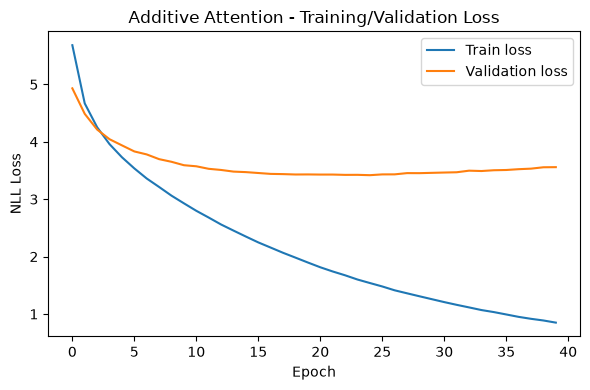

In [6]:
plot_losses(train_losses, val_losses, "Additive Attention - Training/Validation Loss",
            save_path="../outputs/figures/03_additive_loss.png")

In [7]:
evaluateRandomly(encoder, decoder, test_pairs, input_lang, output_lang, n=10, seed=RANDOM_STATE)

> was ist heutzutage nur mit den kindern los ?
= what s going on with children these days ?
< what s your favorite concert off the microphone ?

> ist das wirklich alles ?
= is that really all ?
< is that really knows that ?

> hast du pfannkuchen gegessen ?
= did you have pancakes ?
< have you read this movie ?

> ich akzeptiere deine bedingungen
= i accept your terms
< i ve been watching your mind

> er ist hier gestern heil angekommen
= he arrived here safely yesterday
< he is here because of his illness

> viele sind skeptisch
= many people are skeptical
< many many books are

> legen sie ihm handschellen an
= cuff him
< try harder in this

> tom zog die vorhange zu ehe er sich entkleidete
= tom closed the curtains before he got undressed
< tom zipped the same age

> ich wei noch wie wutend du mich gemacht hast
= i remember how angry you made me
< i know how to you about me

> dieses pedal ist schwergangig
= this pedal is stiff
< this is one is effective



In [8]:
def showAttention(input_sentence, output_words, attentions, save_path=None):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='viridis')
    fig.colorbar(cax)
    xlabels = input_sentence.split(' ') + ['<EOS>']
    ax.set_xticks(list(range(len(xlabels)))); ax.set_xticklabels(xlabels, rotation=90)
    ax.set_yticks(list(range(len(output_words)))); ax.set_yticklabels(output_words)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()


def evaluateAndShowAttention(input_sentence, save_path=None):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence); print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :].detach().cpu(), save_path)

input = die spaghetti die tom macht schmecken mir uberhaupt nicht
output = the earth who tom doesn t want to play chess


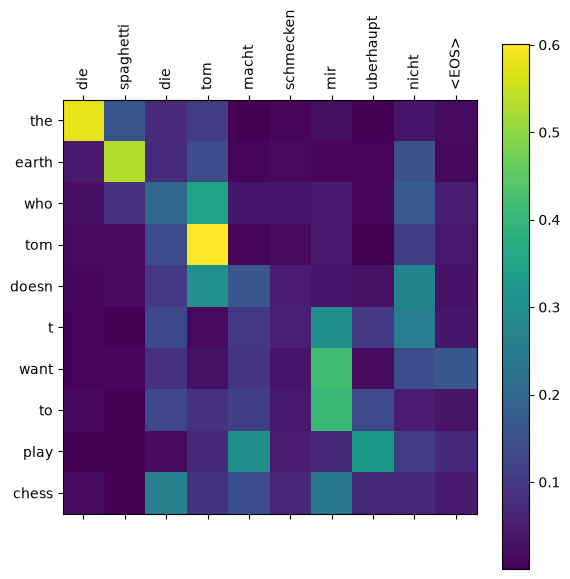

In [9]:
evaluateAndShowAttention(test_pairs[0][0], save_path="../outputs/figures/03_additive_attention_heatmap.png")

In [10]:
bleu = compute_bleu(encoder, decoder, test_pairs, input_lang, output_lang)
print(f"Corpus BLEU-4 (test set, n={len(test_pairs)}): {bleu:.4f}")

Corpus BLEU-4 (test set, n=800): 0.1067


In [11]:

train_ppl = perplexity(train_losses[-1])
val_ppl = perplexity(val_losses[-1])
best_val_ppl = perplexity(min(val_losses))
print(f"Perplexity -> train: {train_ppl:.2f} | val: {val_ppl:.2f} | best val: {best_val_ppl:.2f}")

avg_latency_ms, throughput = measure_inference_latency(encoder, decoder, test_pairs, input_lang, output_lang, n=100)
print(f"Inference latency: {avg_latency_ms:.2f} ms/sentence | Throughput: {throughput:.1f} sentences/sec")

Perplexity -> train: 2.34 | val: 35.10 | best val: 30.52
Inference latency: 2.60 ms/sentence | Throughput: 384.9 sentences/sec


In [12]:
save_result("03_Additive_Attention", {
    "architecture": "Encoder-Decoder + Additive (Bahdanau) Attention",
    "hidden_size": hidden_size, "batch_size": 64, "epochs": EPOCHS,
    "trainable_params": n_params,
    "final_train_loss": train_losses[-1], "final_val_loss": val_losses[-1],
    "train_losses": train_losses, "val_losses": val_losses,
    "test_bleu": bleu, "test_set_size": len(test_pairs),
    "train_perplexity": train_ppl,
    "val_perplexity": val_ppl,
    "best_val_perplexity": best_val_ppl,
    "avg_inference_latency_ms": avg_latency_ms,
    "inference_throughput_sentences_per_sec": throughput
})

Saved results for '03_Additive_Attention' -> d:\NMT_F\nmt-comparison\src\..\outputs\results.json


### Discussion & Conclusion

The Encoder-Decoder model with Bahdanau attention was trained for 40 epochs. The training loss decreased steadily from 5.68 at epoch 1 to 0.85 at epoch 40, showing that the model continued learning the training data. The validation loss decreased from 4.93 to a minimum of 3.41 around epoch 25, after which it gradually increased to 3.55 at epoch 40. This indicates that the model began to overfit after around epoch 25, as the training loss continued to decrease while validation loss started to increase.

The model achieved a Corpus BLEU-4 score of 0.1067 on the held-out test set, which is a substantial improvement over the previous Encoder-Decoder model without attention (0.0114). This shows that adding Bahdanau attention significantly improved the model's translation performance.

Qualitatively, the translations are still imperfect, but some outputs correctly capture the meaning of the source sentence, such as "ist das wirklich alles?" translated as "is that really all?". Other translations remain incorrect or unrelated, like "hast du pfannkuchen gegessen?" translated as "have you read this movie?". 
The attention heatmap (saved to `outputs/figures/03_additive_attention_heatmap.png`) shows the decoder distributing weight across multiple source positions per generated word rather than depending on a single fixed vector - the mechanism attention theory credits for this improvement.

Overall, Bahdanau attention reduces the fixed-context-vector limitation by allowing the Decoder to focus on different Encoder hidden states when generating each target word, resulting in substantially better translation quality than the Encoder-Decoder model without attention.

